# Mini Project: Part B

# Retail Transaction Insights

**By: Venkat Phani Kiran**

**Date: 12th Sep 2026**

---

## Sources

1. Graded Mini Project Part B Retail Transaction Insights.pdf (instructions)
2. Retail_Transactions_Dataset.csv (data, read from Google Drive)

## Problem Statement

A nationwide retail chain is exploring customer behaviour and seasonal trends to improve its strategic decision-making. As the data analyst, the task is to uncover actionable insights from past transaction records. The leadership team is particularly interested in patterns related to purchases, customer segments, promotional impact and seasonal performance.

## Objective and Approach

Analyse the transactions to examine purchase patterns, customer behaviour, promotional impact and seasonal performance. The work follows the six tasks set in the instructions, then checks that the grouped results add back to the full dataset, and closes with key insights, recommended actions and limitations.

| Task | Question area |
|---|---|
| 1 | Data preparation: read the file, convert dates, extract date parts, clean and check |
| 2 | Basic exploration: transactions, customers, top products, top cities |
| 3 | Customer behaviour: spending, payment methods, store types |
| 4 | Promotion and discount impact |
| 5 | Seasonality trends |
| 6 | Visualisation dashboard |

## Assumptions and Design Choices

1. Each row is one transaction, so the row count is the transaction count.
2. The word None in the Promotion column means no promotion; it is kept as a label and not treated as a missing value.
3. Customer_Name is the only customer field, so the number of distinct names estimates the number of customers.
4. Product is a list of item names written as text; it is converted into a real list to count product appearances. Appearances are not unit quantities.
5. Total_Items and Season are used as supplied; where they disagree with the product list or the calendar month, the disagreement is reported and not corrected.
6. Total_Cost is treated as revenue; the data gives no currency.
7. Seasons are shown in the order Spring, Summer, Fall, Winter.

## Setup

Import the three libraries used in this notebook and connect to Google Drive, where the CSV file is stored.

### Import the libraries and connect Google Drive

In [ ]:
# Import pandas for tables and calculations.
import pandas as pd
# Import matplotlib for charts.
import matplotlib.pyplot as plt
# Import seaborn for the heatmap.
import seaborn as sns
# Import the Google Drive connection tool available in Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Data Preparation

Read the file from Google Drive, look at its size, types and labels, convert the dates, add date parts, and clean the text fields. The checks at the end record what was found and what was done about it.

### 1.1 Read the CSV file from Google Drive

In [ ]:
# Store the Drive folder of the course (this now points directly to the CSV file).
COURSE_FOLDER = '/content/drive/MyDrive/IITM AI & Agentic Course Aug 2026/Colab Notebooks/Assignment_1_W4/Part B/Retail_Transactions_Dataset.csv'
# The DATA_CSV should be the actual path to the CSV file.
DATA_CSV = COURSE_FOLDER
# Read the CSV; keep the word None in the Promotion column as a label, not a missing value.
df = pd.read_csv(DATA_CSV, keep_default_na=False, na_values=[''])
# Remember the original column names for the duplicate check later.
source_columns = list(df.columns)
# Show the first five rows turned sideways so that all 13 columns fit on the page.
df.head().T

,0,1,2,3,4
Transaction_ID,1000000000,1000000001,1000000002,1000000003,1000000004
Date,2022-01-21 06:27:29,2023-03-01 13:01:21,2024-03-21 15:37:04,2020-10-31 09:59:47,2020-12-10 00:59:59
Customer_Name,Stacey Price,Michelle Carlson,Lisa Graves,Mrs. Patricia May,Susan Mitchell
Product,"['Ketchup', 'Shaving Cream', 'Light Bulbs']","['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",['Spinach'],"['Tissues', 'Mustard']",['Dish Soap']
Total_Items,3,2,6,1,10
Total_Cost,71.65,25.93,41.49,39.34,16.42
Payment_Method,Mobile Payment,Cash,Credit Card,Mobile Payment,Debit Card
City,Los Angeles,San Francisco,Houston,Chicago,Houston
Store_Type,Warehouse Club,Specialty Store,Department Store,Pharmacy,Specialty Store
Discount_Applied,True,True,True,True,False


### 1.2 How many rows and columns are there?

In [ ]:
# Print the number of rows, which is the number of transactions.
print('Rows:', df.shape[0])
# Print the number of columns.
print('Columns:', df.shape[1])

Rows: 1000000
Columns: 13


### 1.3 What are the column names and data types?

In [ ]:
# Show the column names, their data types and the count of filled values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          1000000 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB


### 1.4 What do the two numeric columns look like?

In [ ]:
# Show count, mean, spread, minimum, quartiles and maximum of the two numeric columns.
df[['Total_Items', 'Total_Cost']].describe().round(2)

,Total_Items,Total_Cost
count,1000000.00,1000000.00
mean,5.50,52.46
std,2.87,27.42
min,1.00,5.00
25%,3.00,28.71
50%,5.00,52.42
75%,8.00,76.19
max,10.00,100.00


### 1.5 How often does each label occur in the category columns?

In [ ]:
# List the columns that hold category labels; City has its own question in Task 2.
label_columns = ['Payment_Method', 'Store_Type', 'Customer_Category', 'Season']
# Add the promotion and discount columns.
label_columns = label_columns + ['Promotion', 'Discount_Applied']
# Go through the label columns one at a time.
for column in label_columns:
    # Leave a blank line before each column.
    print()
    # Print how many transactions carry each label; the column name appears as the heading.
    print(df[column].value_counts())


Payment_Method
Cash              250230
Debit Card        250074
Credit Card       249985
Mobile Payment    249711
Name: count, dtype: int64

Store_Type
Supermarket          166936
Pharmacy             166915
Convenience Store    166749
Warehouse Club       166685
Department Store     166614
Specialty Store      166101
Name: count, dtype: int64

Customer_Category
Senior Citizen    125485
Homemaker         125418
Teenager          125319
Retiree           125072
Student           124842
Professional      124651
Middle-Aged       124636
Young Adult       124577
Name: count, dtype: int64

Season
Spring    250368
Fall      250248
Winter    249763
Summer    249621
Name: count, dtype: int64

Promotion
None                          333943
Discount on Selected Items    333370
BOGO (Buy One Get One)        332687
Name: count, dtype: int64

Discount_Applied
True     500104
False    499896
Name: count, dtype: int64


### 1.6 Parse and convert the Date column

In [ ]:
# Convert the Date text into real date-time values; unreadable text becomes NaT (not a time).
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
# Count the dates that could not be converted.
print('Dates that could not be converted:', df['Date'].isna().sum())
# Show the first five converted dates.
print(df['Date'].head())

Dates that could not be converted: 0
0   2022-01-21 06:27:29
1   2023-03-01 13:01:21
2   2024-03-21 15:37:04
3   2020-10-31 09:59:47
4   2020-12-10 00:59:59
Name: Date, dtype: datetime64[ns]


### 1.7 Extract Year, Month, DayOfWeek and YearMonth from the Date

In [ ]:
# Take the year out of each date.
df['Year'] = df['Date'].dt.year
# Take the month number, 1 to 12, out of each date.
df['Month'] = df['Date'].dt.month
# Take the weekday name out of each date.
df['DayOfWeek'] = df['Date'].dt.day_name()
# Keep the year and month together, for example 2022-01, for the monthly trend.
df['YearMonth'] = df['Date'].dt.to_period('M')
# Show the date and the new date parts together.
df[['Date', 'Year', 'Month', 'DayOfWeek', 'YearMonth']].head()

,Date,Year,Month,DayOfWeek,YearMonth
0,2022-01-21 06:27:29,2022,1,Friday,2022-01
1,2023-03-01 13:01:21,2023,3,Wednesday,2023-03
2,2024-03-21 15:37:04,2024,3,Thursday,2024-03
3,2020-10-31 09:59:47,2020,10,Saturday,2020-10
4,2020-12-10 00:59:59,2020,12,Thursday,2020-12


### 1.8 Are any values missing?

In [ ]:
# Count the missing values in every column.
df.isna().sum()

,0
Transaction_ID,0
Date,0
Customer_Name,0
Product,0
Total_Items,0
Total_Cost,0
Payment_Method,0
City,0
Store_Type,0
Discount_Applied,0


### 1.9 Are there duplicate rows or duplicate transaction IDs?

In [ ]:
# Count rows that repeat an earlier row in all of the original columns.
print('Duplicate rows:', df.duplicated(subset=source_columns).sum())
# Count transaction IDs that repeat an earlier ID.
print('Duplicate transaction IDs:', df['Transaction_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate transaction IDs: 0


### 1.10 Remove unnecessary spaces and inspect the labels

In [ ]:
# List the original text columns; Date is now a date-time column, so it is left out.
text_columns = ['Customer_Name', 'Product', 'Payment_Method', 'City', 'Store_Type']
# Add the remaining text columns.
text_columns = text_columns + ['Customer_Category', 'Season', 'Promotion']
# Go through the text columns one at a time.
for column in text_columns:
    # Remove spaces at the start and end of every value in this column.
    df[column] = df[column].str.strip()
# Show the distinct promotion labels.
print('Promotion labels:', df['Promotion'].unique())
# Show the distinct season labels.
print('Season labels:', df['Season'].unique())
# Show the distinct discount values.
print('Discount values:', df['Discount_Applied'].unique())

Promotion labels: ['None' 'BOGO (Buy One Get One)' 'Discount on Selected Items']
Season labels: ['Winter' 'Fall' 'Spring' 'Summer']
Discount values: [ True False]


### 1.11 Convert the Product text into Python lists

In [ ]:
# Define a helper that turns a list written as text into a real Python list.
def text_to_list(text):
    # Remove the square brackets at both ends.
    inner = text.strip('[]')
    # Split the remaining text at the commas.
    parts = inner.split(',')
    # Start with an empty list of product names.
    items = []
    # Clean each part.
    for part in parts:
        # Remove outer spaces and the quote marks around the name.
        name = part.strip().strip("'\"")
        # Keep names that are not empty.
        if name != '':
            # Add the clean name to the list.
            items.append(name)
    # Give back the list of product names.
    return items
# Apply the helper to every transaction and keep the result in a new column.
df['Product_List'] = df['Product'].apply(text_to_list)
# Compare the original text with the new lists.
df[['Product', 'Product_List']].head()

,Product,Product_List
0,"['Ketchup', 'Shaving Cream', 'Light Bulbs']","[Ketchup, Shaving Cream, Light Bulbs]"
1,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...","[Ice Cream, Milk, Olive Oil, Bread, Potatoes]"
2,['Spinach'],[Spinach]
3,"['Tissues', 'Mustard']","[Tissues, Mustard]"
4,['Dish Soap'],[Dish Soap]


### 1.12 Did the product lists convert cleanly?

In [ ]:
# Count the products in each transaction's list.
listed_items = df['Product_List'].apply(len)
# Count transactions whose list came out empty.
print('Empty product lists:', (listed_items == 0).sum())
# Put every product name of every transaction into one long column.
all_products = df['Product_List'].explode()
# Look for names that still contain a bracket.
has_bracket = all_products.str.contains('[', regex=False)
# Look for names that still contain a quote mark.
has_quote = all_products.str.contains("'", regex=False)
# Combine the two problems.
leftover = has_bracket | has_quote
# Print the count; anything above zero would mean a conversion problem.
print('Names with leftover brackets or quotes:', leftover.sum())
# Print the number of distinct product names.
print('Distinct product names:', all_products.nunique())

Empty product lists: 0
Names with leftover brackets or quotes: 0
Distinct product names: 81


### 1.13 Does the product list agree with Total_Items?

In [ ]:
# Count transactions where the list length and the supplied item count differ.
item_mismatch = (listed_items != df['Total_Items']).sum()
# Print the count.
print('Transactions where the list length differs from Total_Items:', item_mismatch)

Transactions where the list length differs from Total_Items: 899895


### 1.14 Does the Season label agree with the calendar month?

In [ ]:
# Map the winter months to their usual Northern Hemisphere season.
month_to_season = {12: 'Winter', 1: 'Winter', 2: 'Winter'}
# Add the spring months.
month_to_season.update({3: 'Spring', 4: 'Spring', 5: 'Spring'})
# Add the summer months.
month_to_season.update({6: 'Summer', 7: 'Summer', 8: 'Summer'})
# Add the autumn months.
month_to_season.update({9: 'Fall', 10: 'Fall', 11: 'Fall'})
# Work out the season that each transaction's month falls in.
month_season = df['Month'].map(month_to_season)
# Count transactions whose supplied season differs from the month-based season.
season_mismatch = (month_season != df['Season']).sum()
# Print the count.
print('Transactions where Season differs from the calendar month:', season_mismatch)

Transactions where Season differs from the calendar month: 750358


### 1.15 What period does the data cover?

In [ ]:
# Print the earliest transaction time.
print('First transaction:', df['Date'].min())
# Print the latest transaction time.
print('Last transaction:', df['Date'].max())

First transaction: 2020-01-01 00:03:54
Last transaction: 2024-05-18 19:31:03


### 1.16 Cleaning summary

In [ ]:
# Start an empty list of check results.
checks = []
# Define a helper that records one check: what was checked, what was found, what was done.
def add_check(name, found, action):
    # Store the three values as one row.
    checks.append({'Check': name, 'Found': found, 'Action': action})
# Record the missing-value check.
add_check('Missing values', int(df[source_columns].isna().sum().sum()), 'Nothing to fill')
# Record the duplicate-row check.
add_check('Duplicate rows', int(df.duplicated(subset=source_columns).sum()), 'Nothing removed')
# Count the duplicate IDs again for the record.
duplicate_ids = int(df['Transaction_ID'].duplicated().sum())
# Record the duplicate-ID check.
add_check('Duplicate transaction IDs', duplicate_ids, 'Nothing removed')
# Record the date conversion check.
add_check('Dates not converted', int(df['Date'].isna().sum()), 'All dates usable')
# Record the text cleaning.
add_check('Outer spaces in text', 'Not counted', 'Removed from all text columns')
# Record the product conversion check.
add_check('Empty product lists', int((listed_items == 0).sum()), 'Text converted to lists')
# Record the item-count comparison.
add_check('List length differs from Total_Items', int(item_mismatch), 'Kept as supplied')
# Record the season comparison.
add_check('Season differs from calendar month', int(season_mismatch), 'Kept as supplied')
# Show the checks as a table.
pd.DataFrame(checks)

,Check,Found,Action
0,Missing values,0,Nothing to fill
1,Duplicate rows,0,Nothing removed
2,Duplicate transaction IDs,0,Nothing removed
3,Dates not converted,0,All dates usable
4,Outer spaces in text,Not counted,Removed from all text columns
5,Empty product lists,0,Text converted to lists
6,List length differs from Total_Items,899895,Kept as supplied
7,Season differs from calendar month,750358,Kept as supplied


**Data preparation findings.** The file holds **1,000,000 transactions and 13 columns**, covering **1 January 2020 to 18 May 2024**. There are no missing values, no duplicate rows and no duplicate transaction IDs, and every date converted. Each label in the category columns occurs with an almost equal share, which is the first sign that the data is evenly spread. The word None in Promotion was kept as the no-promotion label. Outer spaces were removed from the text columns and every Product text converted into a clean list. Two supplied fields do not agree with the rest of the row: the product list length differs from Total_Items in **899,895 transactions** and the Season label differs from the calendar month in **750,358 transactions**. Both are reported and used as supplied; Total_Items remains the measure of basket size, and the product lists give appearance counts.

## Task 2: Basic Exploration

Answer the four basic questions: how many transactions and customers there are, which products appear most often and which cities have the most transactions. The extracted DayOfWeek is used to see whether any weekday stands out.

### 2.1 How many total transactions are there?

In [ ]:
# Count one transaction per row.
total_transactions = len(df)
# Print the total.
print('Total transactions:', total_transactions)

Total transactions: 1000000


### 2.2 How many unique customers are in the dataset?

In [ ]:
# Count the distinct customer names.
unique_customers = df['Customer_Name'].nunique()
# Print the count; names are the only customer field available.
print('Unique customer names:', unique_customers)

Unique customer names: 329738


### 2.3 What are the top 5 most common products sold across all transactions?

In [ ]:
# Count how often each product name appears across all transactions and keep the top five.
top_products = all_products.value_counts().head(5)
# Show the top five.
top_products

,count
Product_List,
Toothpaste,73324
Ice Cream,37094
Soap,37076
Jam,36956
Orange,36928


### 2.4 Which cities have the highest number of transactions?

In [ ]:
# Count the transactions in each city, largest first.
city_transactions = df['City'].value_counts()
# Show the counts.
city_transactions

,count
City,
Boston,100566
Dallas,100559
Seattle,100167
Chicago,100059
Houston,100050
New York,100007
Los Angeles,99879
Miami,99839
San Francisco,99808


### 2.5 Which weekday has the most transactions?

In [ ]:
# List the weekdays in calendar order.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Count the transactions on each weekday and put them in calendar order.
day_transactions = df['DayOfWeek'].value_counts().reindex(day_order)
# Show the counts.
day_transactions

,count
DayOfWeek,
Monday,142435
Tuesday,142317
Wednesday,143104
Thursday,143375
Friday,143367
Saturday,143310
Sunday,142092


**Basic exploration findings.** There are **1,000,000 transactions** and **329,738 distinct customer names**. **Boston** has the most transactions (**100,566**) and Atlanta the fewest (99,066), a spread of only 1.5% across the ten cities. **Toothpaste** appears far more often than any other product (**73,324** appearances), followed by Ice Cream (37,094), Soap (37,076), Jam (36,956) and Orange (36,928), which are almost level with each other. Each weekday carries close to one-seventh of the transactions, so no shopping day stands out. Distinct names estimate customers because names are not unique identifiers, and product appearances are not unit quantities.

## Task 3: Customer Behaviour Analysis

Compare the customer categories on average spending, payment method and store type, and compare the store types on basket size and spending.

### 3.1 Which customer categories spend the most on average?

In [ ]:
# Work out the average transaction cost of each customer category.
category_spending = df.groupby('Customer_Category')['Total_Cost'].mean().round(2)
# Show the categories from the highest average to the lowest.
category_spending.sort_values(ascending=False)

,Total_Cost
Customer_Category,
Professional,52.53
Teenager,52.53
Student,52.49
Homemaker,52.46
Young Adult,52.45
Retiree,52.44
Middle-Aged,52.41
Senior Citizen,52.34


### 3.2 Do certain customer categories prefer specific payment methods? (counts)

In [ ]:
# Count the transactions for every combination of customer category and payment method.
payment_counts = pd.crosstab(df['Customer_Category'], df['Payment_Method'])
# Show the counts.
payment_counts

Payment_Method,Cash,Credit Card,Debit Card,Mobile Payment
Customer_Category,,,,
Homemaker,31360,31413,31315,31330
Middle-Aged,31078,31049,31198,31311
Professional,31246,31201,31118,31086
Retiree,31269,31408,31051,31344
Senior Citizen,31442,31425,31420,31198
Student,31307,31058,31287,31190
Teenager,31203,31467,31322,31327
Young Adult,31325,30964,31363,30925


### 3.3 Payment methods as a percentage of each customer category

In [ ]:
# Turn each row into shares of that category's transactions.
payment_percent = pd.crosstab(df['Customer_Category'], df['Payment_Method'], normalize='index')
# Turn the shares into percentages.
payment_percent = payment_percent * 100
# Show the percentages; each row adds up to 100.
payment_percent.round(2)

Payment_Method,Cash,Credit Card,Debit Card,Mobile Payment
Customer_Category,,,,
Homemaker,25.00,25.05,24.97,24.98
Middle-Aged,24.94,24.91,25.03,25.12
Professional,25.07,25.03,24.96,24.94
Retiree,25.00,25.11,24.83,25.06
Senior Citizen,25.06,25.04,25.04,24.86
Student,25.08,24.88,25.06,24.98
Teenager,24.90,25.11,24.99,25.00
Young Adult,25.15,24.86,25.18,24.82


### 3.4 What is the average number of items and average spend per transaction per store type?

In [ ]:
# Work out the average item count and average cost of the transactions in each store type.
store_summary = df.groupby('Store_Type')[['Total_Items', 'Total_Cost']].mean().round(2)
# Give the columns clear names.
store_summary.columns = ['Average_Items', 'Average_Cost']
# Show the store types from the largest average basket to the smallest.
store_summary.sort_values('Average_Items', ascending=False)

,Average_Items,Average_Cost
Store_Type,,
Convenience Store,5.51,52.37
Specialty Store,5.51,52.39
Department Store,5.50,52.41
Pharmacy,5.50,52.52
Supermarket,5.49,52.50
Warehouse Club,5.48,52.55


### 3.5 Do customer categories prefer specific store types?

In [ ]:
# Turn each category's store-type counts into percentages of that category's transactions.
store_percent = pd.crosstab(df['Customer_Category'], df['Store_Type'], normalize='index') * 100
# Show the percentages; equal use of six store types would give 16.67 in every cell.
store_percent.round(2)

Store_Type,Convenience Store,Department Store,Pharmacy,Specialty Store,Supermarket,Warehouse Club
Customer_Category,,,,,,
Homemaker,16.60,16.64,16.66,16.62,16.70,16.78
Middle-Aged,16.62,16.91,16.65,16.53,16.69,16.59
Professional,16.75,16.59,16.67,16.73,16.62,16.64
Retiree,16.75,16.54,16.65,16.75,16.70,16.61
Senior Citizen,16.77,16.65,16.73,16.55,16.66,16.63
Student,16.72,16.58,16.87,16.46,16.67,16.70
Teenager,16.65,16.61,16.69,16.58,16.77,16.70
Young Adult,16.52,16.78,16.61,16.65,16.73,16.70


**Customer behaviour findings.** **Teenager** and **Professional** have the highest average spend (**52.53**) and **Senior Citizen** the lowest (**52.34**); the whole range is **0.19**. Every category splits its payments almost equally, with each method between **24.82% and 25.18%**, so no category prefers a payment method. **Specialty Store** and **Convenience Store** have the largest average baskets (**5.51 items**) and Warehouse Club the smallest (5.48), and average spend per store type sits in the same narrow band around 52. Each category also spreads its transactions almost equally over the six store types, close to the 16.67% that equal use would give. These are descriptive differences of a fraction of a percent and should not be read as real behavioural preferences.

## Task 4: Promotion & Discount Impact

Compare transactions with and without a discount, compare basket sizes across promotion types, and test whether any promotion type lifts the transaction value above the no-promotion baseline.

### 4.1 What is the average cost with a discount and without a discount?

In [ ]:
# Count the transactions and average the cost, separately for discount True and False.
discount_summary = df.groupby('Discount_Applied')['Total_Cost'].agg(['count', 'mean']).round(2)
# Give the columns clear names.
discount_summary.columns = ['Transactions', 'Average_Cost']
# Show the comparison.
discount_summary

,Transactions,Average_Cost
Discount_Applied,,
False,499896,52.42
True,500104,52.49


### 4.2 Compare the average number of items purchased for different promotion types

In [ ]:
# Count the transactions and average the item count for each promotion label.
promotion_items = df.groupby('Promotion')['Total_Items'].agg(['count', 'mean']).round(2)
# Give the columns clear names.
promotion_items.columns = ['Transactions', 'Average_Items']
# Show the promotion types from the largest average basket to the smallest.
promotion_items.sort_values('Average_Items', ascending=False)

,Transactions,Average_Items
Promotion,,
Discount on Selected Items,333370,5.50
BOGO (Buy One Get One),332687,5.49
None,333943,5.49


### 4.3 Which promotion type seems most effective in increasing total cost?

In [ ]:
# Count transactions, average the cost and add up the revenue for each promotion label.
promotion_cost = df.groupby('Promotion')['Total_Cost'].agg(['count', 'mean', 'sum'])
# Give the columns clear names.
promotion_cost.columns = ['Transactions', 'Average_Cost', 'Total_Revenue']
# Take the no-promotion average as the baseline.
baseline = promotion_cost.loc['None', 'Average_Cost']
# Work out each promotion's average cost as a percentage above or below the baseline.
promotion_cost['Difference_vs_None_%'] = (promotion_cost['Average_Cost'] / baseline - 1) * 100
# Show the promotion types from the highest average cost to the lowest.
promotion_cost.sort_values('Average_Cost', ascending=False).round(2)

,Transactions,Average_Cost,Total_Revenue,Difference_vs_None_%
Promotion,,,,
None,333943,52.57,17554038.81,0.00
BOGO (Buy One Get One),332687,52.42,17438953.65,-0.28
Discount on Selected Items,333370,52.38,17462227.94,-0.35


**Promotion and discount findings.** The average transaction is **52.49 with a discount** and **52.42 without**, a difference of 0.07 on a base of about 52. **Discount on Selected Items** has the largest average basket (**5.50 items**) against 5.49 for the other two labels. On transaction value, transactions with **no promotion have the highest average cost (52.57)**; BOGO is 0.28% lower and Discount on Selected Items 0.35% lower. Total revenue by promotion mainly reflects the near-equal transaction counts. No promotion type increases the transaction value in this data, and these are observational comparisons: they cannot show what the same customers would have spent without the promotion.

## Task 5: Seasonality Trends

Compare the four seasons on total revenue, store-type mix, product mix and average spending, and plot the average spending per season.

### 5.1 Which season has the highest total revenue?

In [ ]:
# Add up the revenue of each season, largest first.
season_revenue = df.groupby('Season')['Total_Cost'].sum().sort_values(ascending=False)
# Show the totals.
season_revenue.round(2)

,Total_Cost
Season,
Fall,13136913.71
Summer,13116675.79
Spring,13113238.75
Winter,13088392.15


### 5.2 Are there seasonal preferences for certain store types? (counts)

In [ ]:
# Count the transactions for every combination of season and store type.
season_store_counts = pd.crosstab(df['Season'], df['Store_Type'])
# Show the counts.
season_store_counts

Store_Type,Convenience Store,Department Store,Pharmacy,Specialty Store,Supermarket,Warehouse Club
Season,,,,,,
Fall,41654,41593,41852,41606,41526,42017
Spring,41798,41590,41825,41570,41845,41740
Summer,41735,41623,41520,41362,41953,41428
Winter,41562,41808,41718,41563,41612,41500


### 5.3 Store types as a percentage of each season

In [ ]:
# Turn each season's store-type counts into percentages of that season's transactions.
season_store_percent = pd.crosstab(df['Season'], df['Store_Type'], normalize='index') * 100
# Show the percentages; equal use would give 16.67 in every cell.
season_store_percent.round(2)

Store_Type,Convenience Store,Department Store,Pharmacy,Specialty Store,Supermarket,Warehouse Club
Season,,,,,,
Fall,16.65,16.62,16.72,16.63,16.59,16.79
Spring,16.69,16.61,16.71,16.60,16.71,16.67
Summer,16.72,16.67,16.63,16.57,16.81,16.60
Winter,16.64,16.74,16.70,16.64,16.66,16.62


### 5.4 Are there seasonal preferences for certain products?

In [ ]:
# List the seasons in calendar order for all seasonal tables and charts.
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
# Pair every product appearance with the season of its transaction.
season_products = df[['Season', 'Product_List']].explode('Product_List')
# Go through the seasons in order.
for season in season_order:
    # Print the season as a heading.
    print('\nTop 5 products in ' + season)
    # Keep the product appearances of this season.
    in_season = season_products[season_products['Season'] == season]
    # Print the five most frequent products of the season.
    print(in_season['Product_List'].value_counts().head(5))


Top 5 products in Spring
Product_List
Toothpaste        18263
Soap               9397
Honey              9345
Deodorant          9330
Cleaning Spray     9317
Name: count, dtype: int64

Top 5 products in Summer
Product_List
Toothpaste         18345
Ice Cream           9387
Soda                9362
Deodorant           9321
Extension Cords     9291
Name: count, dtype: int64

Top 5 products in Fall
Product_List
Toothpaste       18412
Ironing Board     9435
Peanut Butter     9353
Ice Cream         9331
Coffee            9330
Name: count, dtype: int64

Top 5 products in Winter
Product_List
Toothpaste        18304
Orange             9402
Vacuum Cleaner     9286
Bath Towels        9278
Tomatoes           9264
Name: count, dtype: int64


### 5.5 Average spending per season (table)

In [ ]:
# Work out the average transaction cost of each season and put the seasons in calendar order.
season_average = df.groupby('Season')['Total_Cost'].mean().reindex(season_order)
# Show the averages used in the chart.
season_average.round(2)

,Total_Cost
Season,
Spring,52.38
Summer,52.55
Fall,52.50
Winter,52.40


### 5.6 Average spending per season (chart)

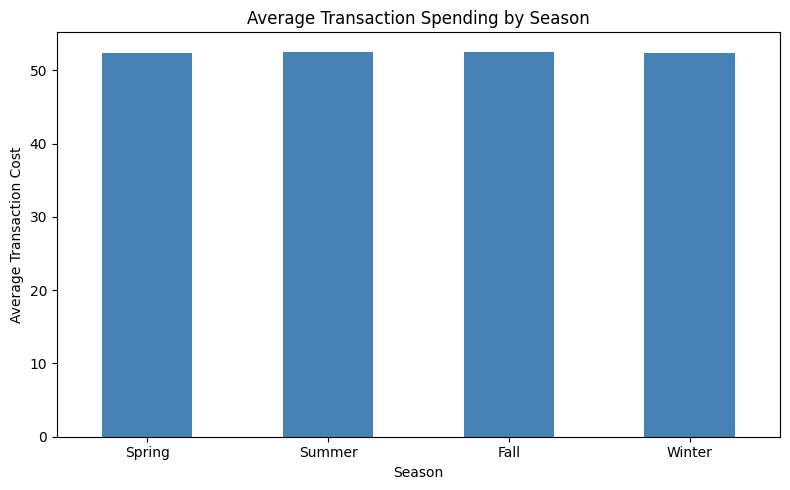

In [ ]:
# Draw a bar for each season's average transaction cost.
season_average.plot(kind='bar', figsize=(8, 5), color='steelblue', rot=0)
# Give the chart a title.
plt.title('Average Transaction Spending by Season')
# Label the horizontal axis.
plt.xlabel('Season')
# Label the vertical axis.
plt.ylabel('Average Transaction Cost')
# Fit the labels inside the figure.
plt.tight_layout()
# Show the chart.
plt.show()

*Observation: the four bars are almost the same height; the averages run from 52.38 (Spring) to 52.55 (Summer), a spread of 0.17.*

**Seasonality findings.** **Fall** has the highest total revenue (**13,136,913.71**) and Winter the lowest (13,088,392.15), a gap of 0.4%. **Summer** has the highest average transaction spending (**52.55**) and Spring the lowest (52.38). Every store type takes between **16.57% and 16.81%** of each season's transactions, so the store mix does not change with the season. Toothpaste is the most frequent product in every season and the next four places are near-ties that change from season to season by chance rather than by preference. Because the Season label disagrees with the calendar month in three quarters of the rows, these are results for the supplied labels and not evidence of real calendar seasonality.

## Task 6: Visualisation Dashboard

Four required charts: transactions per city, the payment-method split, the monthly revenue trend (also grouped by year) and revenue by season and customer category. Each chart is followed by a one-line observation.

### 6.1 Bar plot of the number of transactions per city

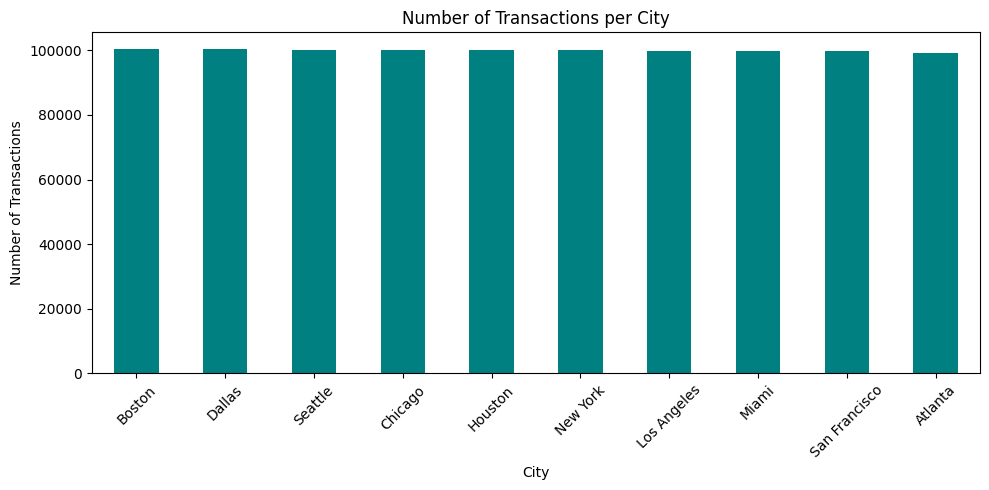

In [ ]:
# Draw a bar for each city's transaction count and tilt the city names so they do not overlap.
city_transactions.plot(kind='bar', figsize=(10, 5), color='teal', rot=45)
# Give the chart a title.
plt.title('Number of Transactions per City')
# Label the horizontal axis.
plt.xlabel('City')
# Label the vertical axis.
plt.ylabel('Number of Transactions')
# Fit the labels inside the figure.
plt.tight_layout()
# Show the chart.
plt.show()

*Observation: every city has close to 100,000 transactions; Boston leads with 100,566 and Atlanta trails with 99,066.*

### 6.2 Pie chart showing the distribution of payment methods

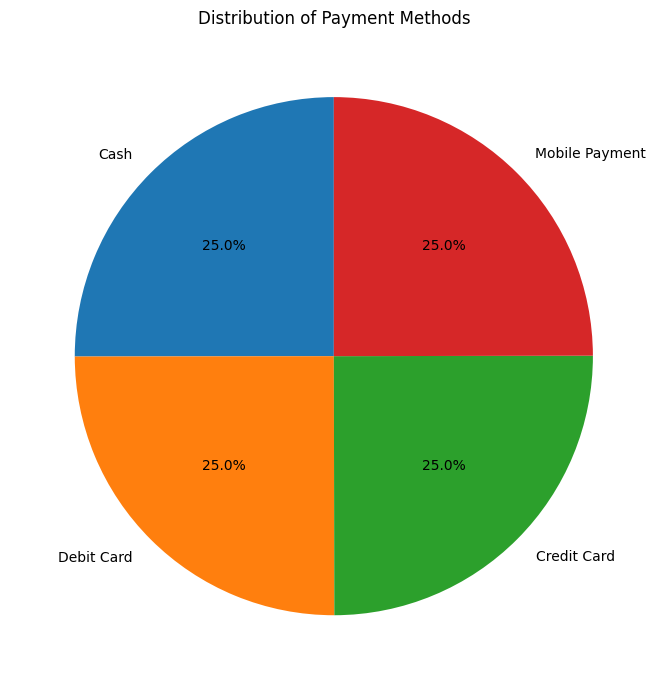

In [ ]:
# Count the transactions for each payment method.
payment_distribution = df['Payment_Method'].value_counts()
# Draw a pie with one slice per payment method and the percentage written on each slice.
payment_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(7, 7))
# Give the chart a title.
plt.title('Distribution of Payment Methods')
# Remove the default label on the vertical axis.
plt.ylabel('')
# Fit the labels inside the figure.
plt.tight_layout()
# Show the chart.
plt.show()

*Observation: the four payment methods each take 25.0% of transactions; none is preferred.*

### 6.3 Monthly revenue by year (table, in millions)

In [ ]:
# Add up the revenue for every year and month, with years as rows and months as columns.
year_month = df.pivot_table(values='Total_Cost', index='Year', columns='Month', aggfunc='sum')
# Show the table in millions with three decimals.
(year_month / 1000000).round(3)

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2020,1.024,0.953,1.016,0.989,1.002,0.989,1.013,1.023,0.989,1.008,0.998,1.013
2021,1.019,0.914,1.022,0.978,1.011,0.991,1.022,1.010,0.971,1.024,0.992,1.015
2022,1.019,0.910,1.017,0.989,1.021,0.997,1.017,1.006,0.977,1.008,0.984,1.002
2023,1.008,0.927,1.034,0.978,1.015,0.966,1.029,1.015,0.985,1.020,0.990,1.017
2024,1.014,0.943,1.019,0.977,0.587,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.4 Line chart of monthly revenue trends

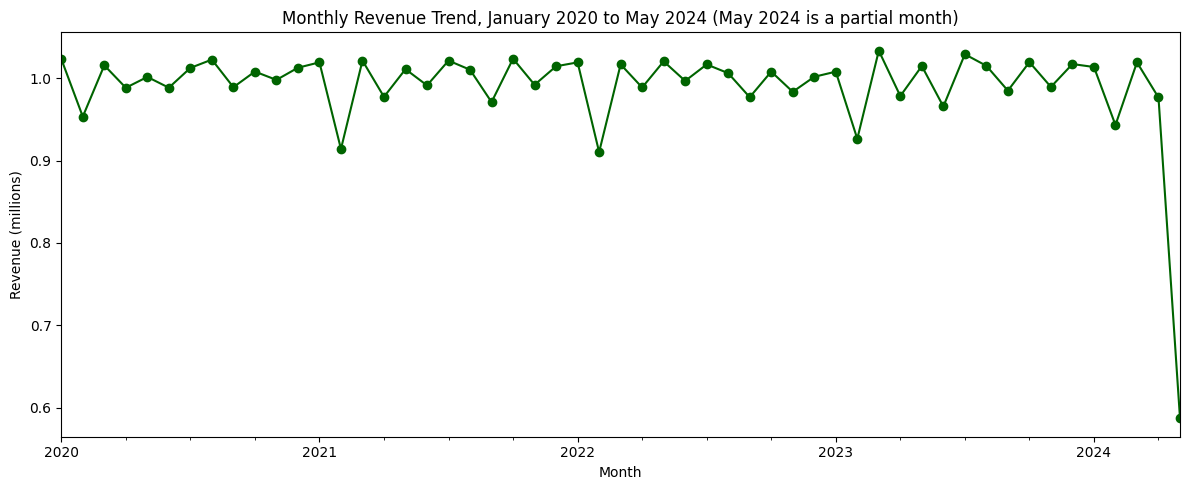

In [ ]:
# Add up the revenue of each year-month in date order.
monthly_revenue = df.groupby('YearMonth')['Total_Cost'].sum()
# Draw the monthly totals in millions as a line with a marker on each month.
(monthly_revenue / 1000000).plot(kind='line', figsize=(12, 5), marker='o', color='darkgreen')
# Give the chart a title that flags the partial final month.
plt.title('Monthly Revenue Trend, January 2020 to May 2024 (May 2024 is a partial month)')
# Label the horizontal axis.
plt.xlabel('Month')
# Label the vertical axis.
plt.ylabel('Revenue (millions)')
# Fit the labels inside the figure.
plt.tight_layout()
# Show the chart.
plt.show()

*Observation: revenue is flat at about 1 million a month for four years; the dip every February is the shorter month, and the drop in May 2024 is because the data ends on 18 May.*

### 6.5 Revenue per day of each month

In [ ]:
# Take the number of days in each month from the year-month index.
days_in_month = monthly_revenue.index.days_in_month
# Divide each month's revenue by its number of days.
revenue_per_day = monthly_revenue / days_in_month
# Leave out the last month, which is not complete.
complete_months = revenue_per_day[:-1]
# Print the lowest revenue per day and its month.
print('Lowest per day:', round(complete_months.min(), 2), 'in', complete_months.idxmin())
# Print the highest revenue per day and its month.
print('Highest per day:', round(complete_months.max(), 2), 'in', complete_months.idxmax())

Lowest per day: 32193.99 in 2023-06
Highest per day: 33340.54 in 2023-03


### 6.6 Line chart of monthly revenue grouped by year

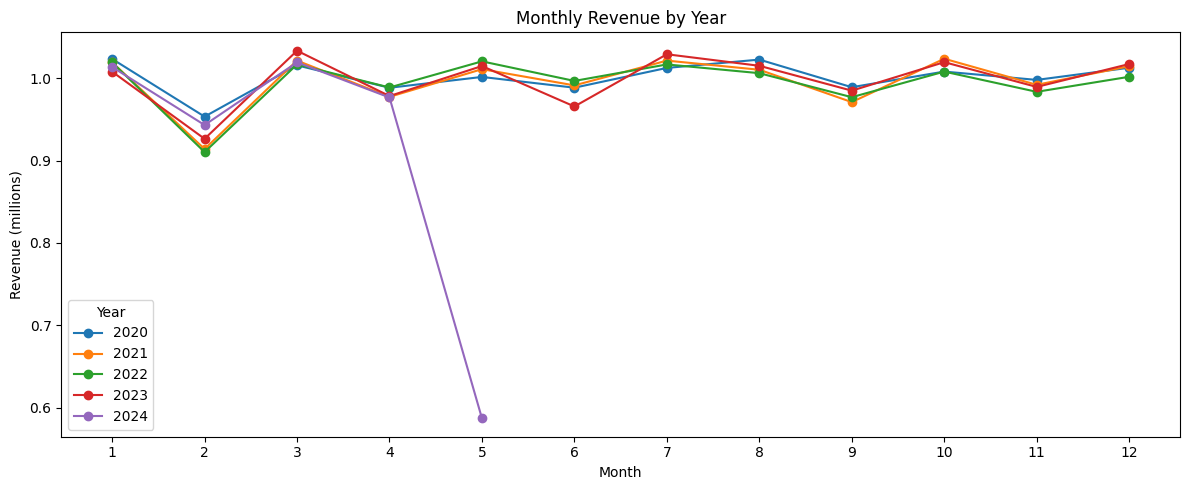

In [ ]:
# Draw one line per year, with the months along the horizontal axis, in millions.
(year_month / 1000000).T.plot(kind='line', figsize=(12, 5), marker='o')
# Give the chart a title.
plt.title('Monthly Revenue by Year')
# Label the horizontal axis.
plt.xlabel('Month')
# Show every month number on the axis.
plt.xticks(range(1, 13))
# Label the vertical axis.
plt.ylabel('Revenue (millions)')
# Title the legend.
plt.legend(title='Year')
# Fit the labels inside the figure.
plt.tight_layout()
# Show the chart.
plt.show()

*Observation: the five years lie on top of each other; February is the lowest complete month in every year, and February 2020 (a leap year with 29 days) is the highest of the Februaries.*

### 6.7 Revenue by season and customer category (table, in millions)

In [ ]:
# Name the column that gives the customer category.
category = 'Customer_Category'
# Name the value column to add up.
value = 'Total_Cost'
# Add up the revenue for every season and customer category.
season_category = df.pivot_table(values=value, index='Season', columns=category, aggfunc='sum')
# Put the seasons in calendar order.
season_category = season_category.reindex(season_order)
# Show the table in millions with three decimals.
(season_category / 1000000).round(3)

Customer_Category,Homemaker,Middle-Aged,Professional,Retiree,Senior Citizen,Student,Teenager,Young Adult
Season,,,,,,,,
Spring,1.641,1.627,1.639,1.628,1.631,1.649,1.652,1.646
Summer,1.639,1.640,1.632,1.652,1.655,1.628,1.639,1.632
Fall,1.648,1.628,1.653,1.641,1.643,1.651,1.646,1.628
Winter,1.651,1.638,1.624,1.637,1.640,1.626,1.646,1.627


### 6.8 Heatmap of revenue by season and customer category

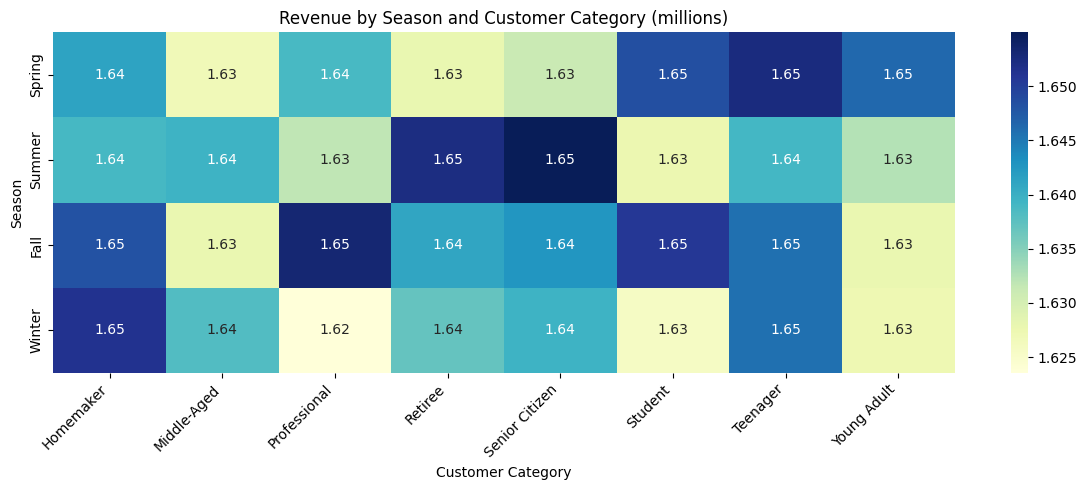

In [ ]:
# Create a figure 12 inches wide and 5 inches tall.
plt.figure(figsize=(12, 5))
# Colour each cell by revenue in millions and write the value in the cell.
sns.heatmap(season_category / 1000000, annot=True, fmt='.2f', cmap='YlGnBu')
# Give the chart a title.
plt.title('Revenue by Season and Customer Category (millions)')
# Label the horizontal axis.
plt.xlabel('Customer Category')
# Label the vertical axis.
plt.ylabel('Season')
# Tilt the category names so they do not overlap.
plt.xticks(rotation=45, ha='right')
# Fit the labels inside the figure.
plt.tight_layout()
# Show the chart.
plt.show()

*Observation: every season and category cell holds between 1.62 and 1.65 million; no segment earns noticeably more in any season.*

**Dashboard findings.** The city and payment charts confirm an even spread of business. The monthly trend is flat at about one million a month; the highest month is **March 2023 (1,033,556.59)** and the lowest complete month in every year is February. Revenue per day stays between about **32,200 and 33,300** in every complete month, so the February dips are a day-count effect and not a fall in demand. **May 2024 (586,965.49)** covers only 18 days and must not be read as a decline. The heatmap shows revenue between 1.62 and 1.65 million in every season and category cell.

## Checks: do the grouped results add back to the full data?

Each grouped table should account for every transaction and every unit of revenue. These checks print True when the totals agree.

### Transactions are all accounted for

In [ ]:
# The city counts must add up to all transactions.
print('City counts add up to all transactions:', city_transactions.sum() == total_transactions)
# The category and payment-method table must add up to all transactions.
print('Payment table adds up to all transactions:', payment_counts.values.sum() == len(df))
# Each row of the payment percentage table must add up to 100.
row_totals = payment_percent.sum(axis=1).round(6)
# Print whether every row total is 100.
print('Payment percentages add up to 100 per row:', (row_totals == 100).all())
# The transaction table must still have one row per transaction after the product work.
print('Row count unchanged after product conversion:', len(df) == total_transactions)

City counts add up to all transactions: True
Payment table adds up to all transactions: True
Payment percentages add up to 100 per row: True
Row count unchanged after product conversion: True


### Revenue is all accounted for

In [ ]:
# Add up the revenue from the transaction table itself.
total_revenue = df['Total_Cost'].sum()
# Print the total revenue.
print('Total revenue:', round(total_revenue, 2))



Total revenue: 52455220.4


In [ ]:
# The monthly totals must add up to the total revenue, allowing for rounding.
print('Monthly revenue adds up:', abs(monthly_revenue.sum() - total_revenue) < 0.01)
# The season totals must add up to the total revenue.
print('Season revenue adds up:', abs(season_revenue.sum() - total_revenue) < 0.01)
# Add up the promotion revenue column.
promotion_total = promotion_cost['Total_Revenue'].sum()
# The promotion totals must add up to the total revenue.
print('Promotion revenue adds up:', abs(promotion_total - total_revenue) < 0.01)
# The heatmap table must add up to the total revenue.
print('Heatmap revenue adds up:', abs(season_category.values.sum() - total_revenue) < 0.01)

Monthly revenue adds up: True
Season revenue adds up: True
Promotion revenue adds up: True
Heatmap revenue adds up: True


## Key Insights

1. **Coverage.** 1,000,000 transactions and 329,738 distinct customer names, 1 January 2020 to 18 May 2024; no missing values or duplicates.
2. **Even spread.** Cities about 100,000 transactions each, payment methods 25% each, store types about one-sixth, customer categories about one-eighth. Boston (100,566) leads the cities and Toothpaste (73,324 appearances) the products.
3. **Customer behaviour.** Average spend by category 52.34 to 52.53; payment shares 24.82% to 25.18%; store-type shares close to 16.67%. No segment stands out.
4. **Promotions.** Discounted transactions average 52.49 against 52.42 without. No promotion has the highest average cost (52.57); BOGO and Discount on Selected Items are 0.28% and 0.35% lower, with no larger baskets.
5. **Seasonality.** Fall leads revenue and Summer leads average spend, both by under 0.5%. Store and product mixes barely change by season; the Season label disagrees with the calendar month in 75% of rows.
6. **Trend.** Revenue is flat at about 1 million a month (32,200 to 33,300 a day) for four years. The February dips are a day-count effect; May 2024 is a partial month.
7. **Data quality.** Total_Items disagrees with the product list in 90% of rows, Season with the month in 75%, and there is no customer identifier.



## Recommended Actions
1. Treat the ten cities and four payment methods as one national market; no city- or payment-specific campaigns are justified.
2. Do not scale BOGO or Discount on Selected Items: neither lifts basket size or transaction value. Test in a controlled trial first.
3. Fix data capture before segment analysis: reconcile Total_Items with the product list, derive Season from the date, add a customer ID.
4. Judge months on revenue per trading day, excluding partial months such as May 2024.
5. Look for differences at product level (Toothpaste appears twice as often as any other product), not at segment level.


## Limitations

1. Names are not customer IDs, so the customer count is an estimate.
2. Product appearances are not unit quantities.
3. Total_Items and the Season label are inconsistent with the rest of the row in most transactions.
4. No currency is given, so amounts are reported without a unit.
5. The file records transaction value, not profit or cost.
6. All comparisons are observational; they describe differences and do not prove causes.

In [ ]:
# Confirm the run reached the end and how many transactions were analysed.
print('End of Part B. Transactions analysed:', len(df))

End of Part B. Transactions analysed: 1000000
